# Iterative Methods and Gradient Descent #17

many algorithm we'll use and discuss (including k-means and tSNE) will be iterative methods. they will start from a guess, and iteratively improve it.

we also want to look at the gradient descent algorithm (that's how tSNE works). it's a simple algorithm which minimizes a function (of one varaible for now). we'll be relying on such algorithms a lot -- including tSNE, neural network training. 


in diemnsion one the idea is that the derivative evaluated at some x tells us two things:

* the direction in which the function grows (positive sign = right, negative sign = left)
* how quickly it grows

so to minimize the function we'll take a small step in some direction, and repeat

In [2]:
import matplotlib.pyplot as plt
import numpy as np

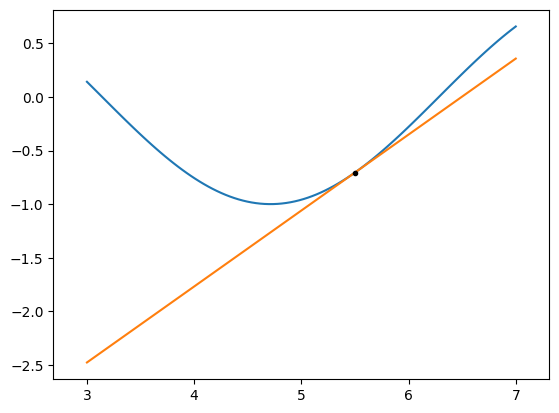

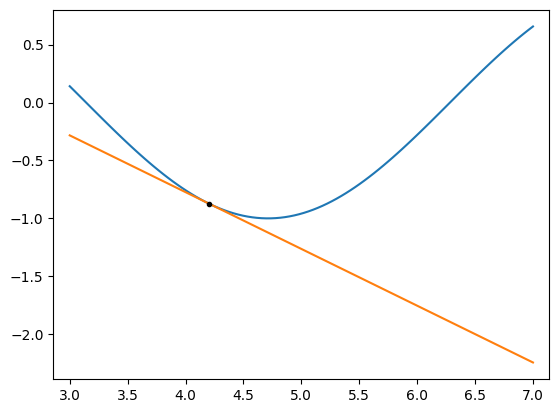

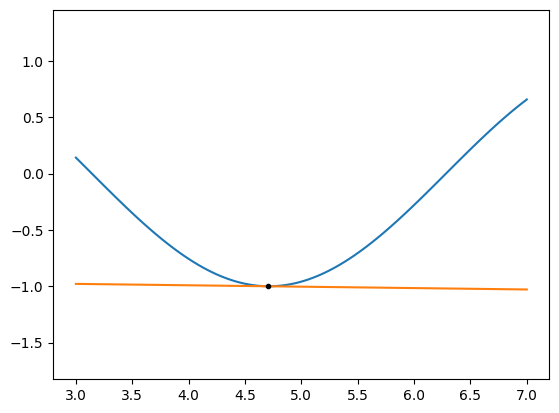

In [4]:
def f(x): return np.sin(x)

def f_der(x): return np.cos(x) # tells us the slop of the graph at x

xs = np.linspace(3, 7, 100)
# here, the only plot it on the interval about x = 3 to x = 7
# the goal is to find the x where f(x) is as small as possible

for x0 in [5.5, 4.2, 4.7]:
    plt.plot(xs, f(xs))
    plt.plot(xs, f(x0) + f_der(x0)*(xs-x0)) # tangent line (orange)
    plt.plot(x0, f(x0), 'k.')
    plt.axis('equal')
    plt.show()

### approximating the derivative (and more generally the gradient) at a point

> note that we're in R so point is just a real number

### Task 1

Choose you favourite function $f$.

Some examples: $x^2+1$ or $\sin(x)+2$ or $\sin(x) + \cos(5x)/2 + 2$

> I added a constant so that the graph of this function is above the x axis. This way the visualization below will be cleaner.

Now implement another function grad_f_at which returns the gradient of $f$ evaluated at some point $x$.

> Tip: gradient is a vector of partial derivatives,
but we have only one variable, so things simplify. But we want to get used to thinking about the gradient at a point as a **vector** (even if it's one dimensional).

Can you implement a function which evaluates (approximates) the gradient of any (reasonable) function $f$ at a point $x$?

In [5]:
def f(x):
    return np.sin(x) + np.cos(5*x)/2 + 2

def grad_f_at(f, x0, dx=1e-8):
    '''
    f: the function
    x0: point where we evaluate derivative
    dx: very small step
    
    in dimensino one the gradient is just the derivative: df/dx
    or in other words we should simply approximate f'(x0)
    '''

    return (f(x0+dx) - f(x0)) / dx 

In [6]:
grad_f_at(f, 3)

np.float64(-2.6157120691649993)

In [7]:
print("answer is:", grad_f_at(f,3))

answer is: -2.6157120691649993


### Task 2: implement and test gradient descent

In [23]:
def grad_descent(f, x0, learning_rate, num_iters):
  '''
  Implements a simple gradient descent
  -We start from x0.
  -grad_f_at returns the gradient of some function at x
  -learning rate controls the step size
  -performs num_iters many iterations
  -returns the full history (all intermediate x's)
  '''
  history = [x0] # this is just to keep track of all steps
  x = x0
  for i in range(num_iters):
    x -= grad_f_at(f, x) * learning_rate

    history.append(x)

  return np.asarray(history) # convert the list to a NumPy array and return it

### Visualization

just run it for different f, starting point etc.

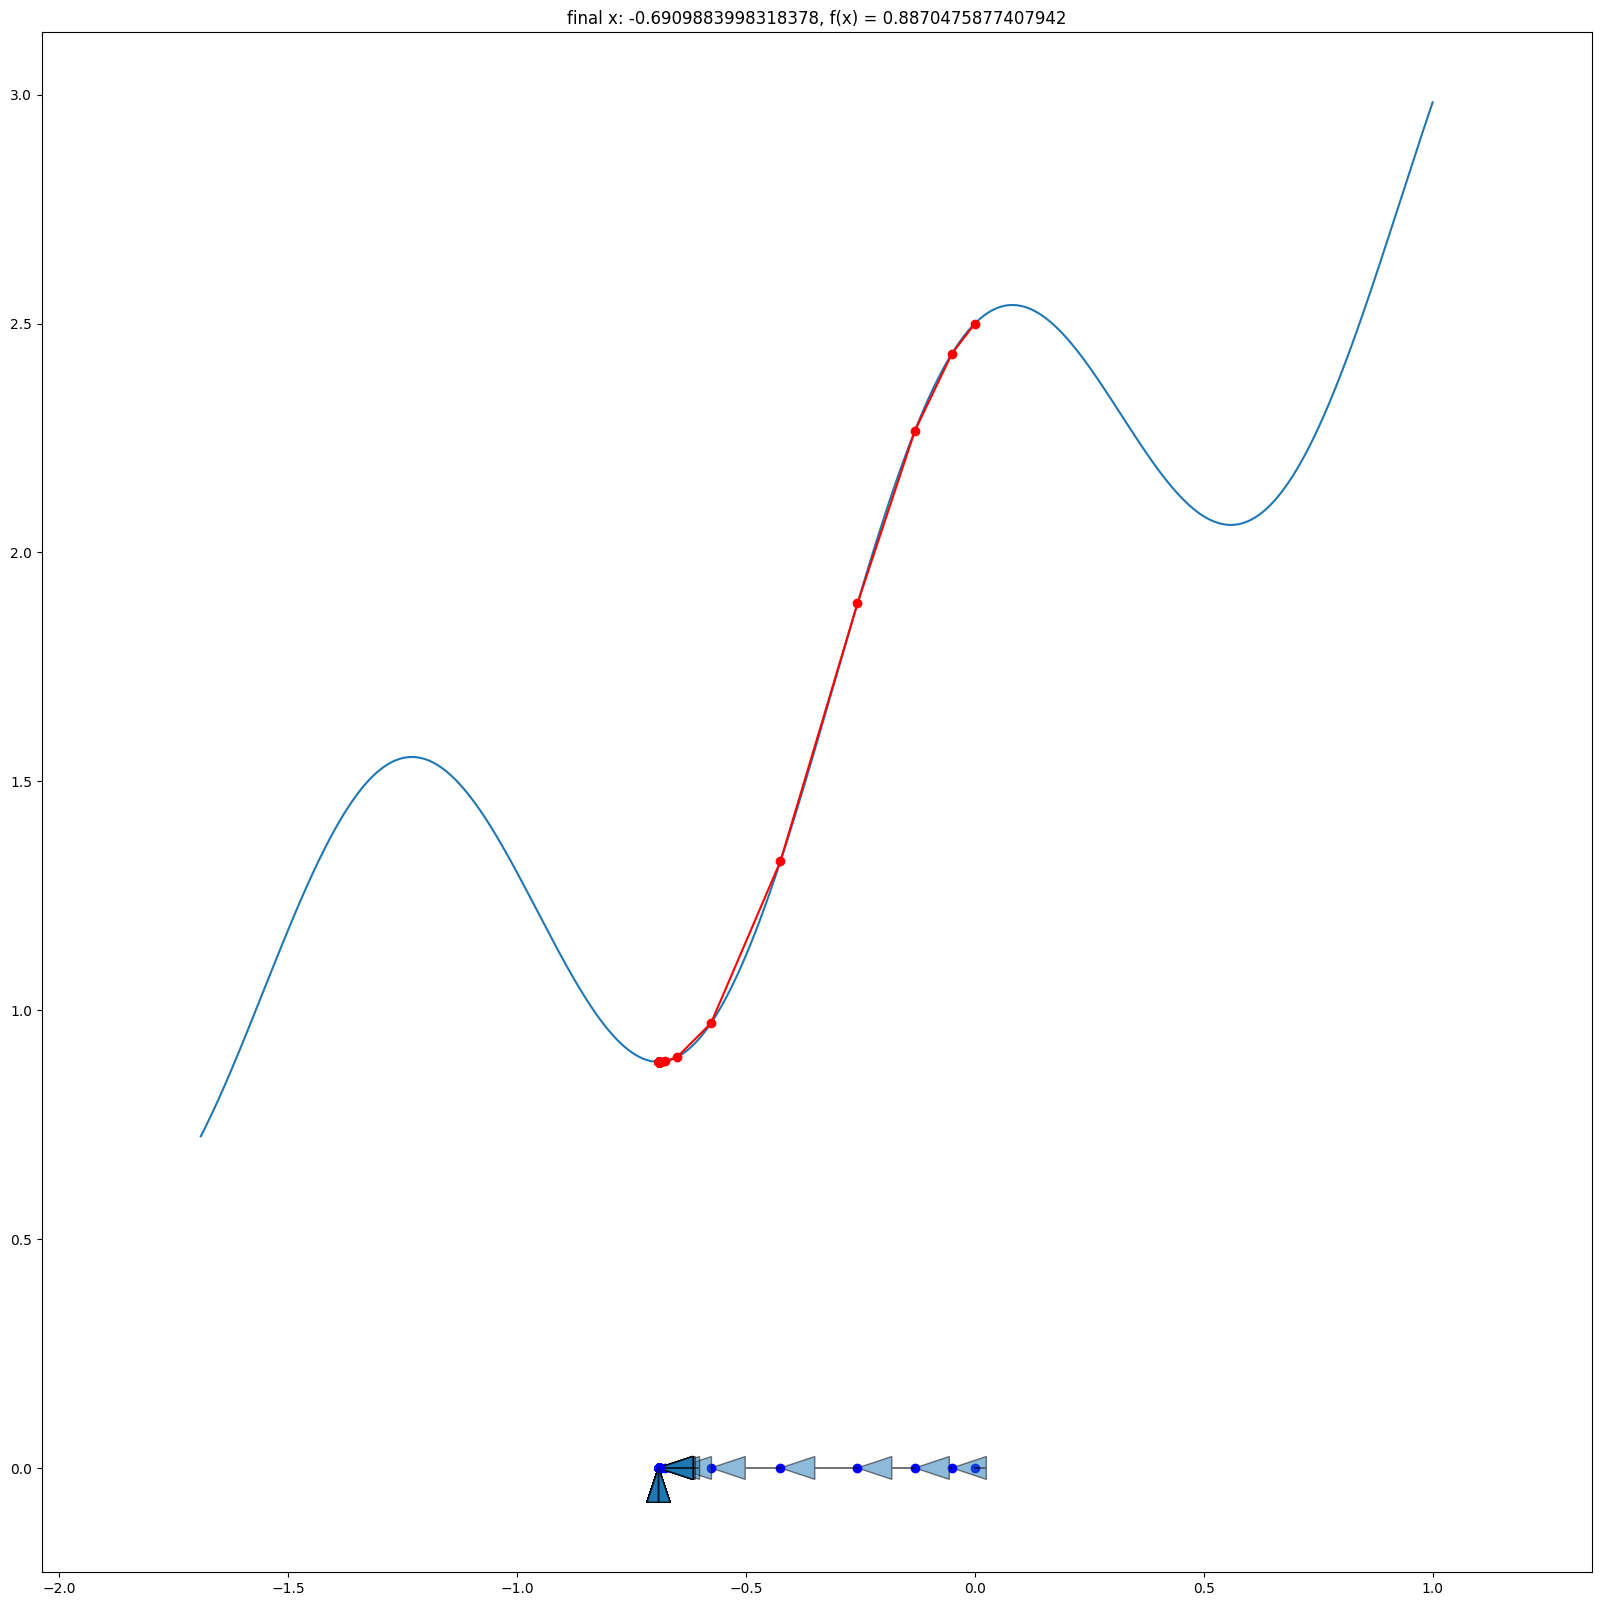

In [20]:
plt.figure(figsize = (20,20))

# you can play with the params below
x0 = np.pi/2 + np.random.randn()/1000
#x0 = 1.279651724440534 + np.random.randn() * 1e-8
#x0 = 0.3

x0 = 0.0

lr = 0.05 # 'learning rate', how quickly we move

hs = grad_descent(f, x0, learning_rate=lr, num_iters=200)

xs = np.linspace(hs.min()-1, hs.max()+1, 1000)
plt.plot(xs, f(xs))

plt.plot(hs, f(hs), 'ro-')
plt.title(f'final x: {hs[-1]}, f(x) = {f(hs[-1])}')

for x in hs:
  plt.scatter([x], [0], c = 'blue')
  plt.arrow(*(x,0), *(-grad_f_at(f, x)*lr,0), length_includes_head=True,
            head_width=0.05, alpha = 0.5)

plt.axis('equal');

In [22]:
#grad_f_at(0, 1e-8)

def grad_f_at(f, x0, dx=1e-8):
    return (f(x0 + dx) - f(x0)) / dx

### New tool: numerical minimization of functions with gradient descent

we'll use the scipy.optimize module for this.

the trick is that if you can represent your problem as a function minimization, you should be able to solve it automatically. 

### Simple usage example

In [24]:
import scipy.optimize as opt

In [25]:
def temperature_shock(a,b):
    return (a-b)**2

In [26]:
a,b = 50, 100

def f(x):
    return temperature_shock(a,x) + temperature_shock(b,x)

best_x = opt.minimize(f, x0=a).x

print(best_x, f(best_x))

[75.00000012] [1250.]


> opt.minimize(...)

so instead of coding the whole gradient descent loop by hand, you call a library function


numerical optimization means using a computer to search for a minimum


### New tool: numerical minimization of functions with gradient descent

> Here are some tricks:
- gradient descent works the same in arbitrary dimension $d$!

> I mean the gradient at a point is now a vector and not a scalar, but the algorithm stays the same! We'll talk about high-dimensional gradient descent some more -- for now let's just use it.

- we can approximate the gradient numerically
- we can use a library function which just takes the function to optimize (and a starting point)

#### Task 2

consider a set of points P and point x. we can compute s(x) as the sum of Euclidean distances from each point in p to x.

leet's try to verify that the arithmetic means of P is the point which minimizes s(x) (among all possible points in R^2)

or can we do this in higher dimension d(except for plotting)?


so, takes points P, define s(x) as the sum of Euclidean distances from each point to x, and check whether the arthmetic mean minimizes it

In [27]:
P = np.random.rand(5,2) # some random points

def f(x):
    '''
    the function to minimize
    '''
    return np.sum(np.linalg.norm(P-x, axis=1))


In [28]:
P.shape

(5, 2)

mean: [0.36068437 0.57730281] f(mean): 2.0414928956652187
best_x: [0.359025   0.64825052] f(best_x): 2.0331648962061606


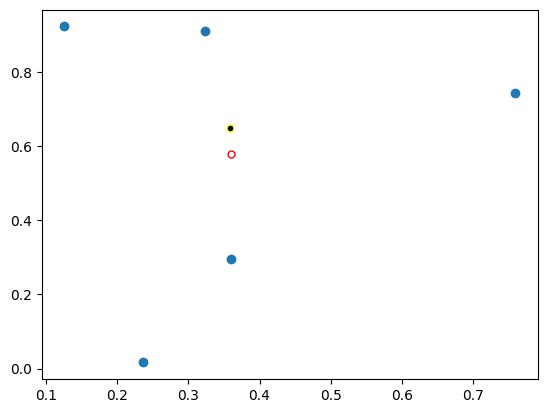

In [35]:
P = np.random.rand(5,2) # some random points

def f(x):
    '''
    the function to minimize
    '''
    return np.sum(np.linalg.norm(P-x, axis=1))

x0 = np.random.rand(2)

optimization_result = opt.minimize(f, x0)
best_x = optimization_result.x

mean = P.mean(axis=0)

print("mean:", mean, "f(mean):", f(mean))
print("best_x:", best_x, "f(best_x):", f(best_x))


plt.scatter(P[:, 0], P[:, 1])
plt.scatter(best_x[0], best_x[1], edgecolors='yellow', c='black', s=25)
plt.scatter(mean[0], mean[1], facecolors='none', edgecolors='r', s=25)